In [1]:
import numpy as np
import pandas as pd
Data = {
    'sample': ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12'],
    'Condition': ['Control','Control','TreatmentA','TreatmentA','Control',
                  'Knockdown','Knockdown','TreatmentB','TreatmentB','Control',
                  'TreatmentA','Knockdown'],
    'Tissue': ['Liver','Heart','Brain','Liver','Brain',
               'Liver','Heart','Brain','Liver','Heart',
               'Brain','Liver'],
    'GeneA': [2.0, 0.5, 1.2, 3.0, 2.5, 1.0, 2.2, 2.8, 1.5, 3.1, 2.0, 2.5],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.8, 0.9, 1.2, 2.0, 1.5, 1.7, 2.3],
    'Phenotype': [5, 3, 6, 9, 8, 4, 7, 10, 6, 11, 7, 9]
}

df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
print(df_encoded)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown','Condition_TreatmentA',
                'Condition_TreatmentB','Tissue_Brain','Tissue_Heart']].values.astype(float)
print(X)
X = np.hstack((np.ones((X.shape[0],1)),X))  # 添加截距项
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)

   sample  GeneA  GeneB  Phenotype  Condition_Control  Condition_Knockdown  \
0      S1    2.0    1.5          5               True                False   
1      S2    0.5    2.2          3               True                False   
2      S3    1.2    0.7          6              False                False   
3      S4    3.0    1.0          9              False                False   
4      S5    2.5    2.5          8               True                False   
5      S6    1.0    1.8          4              False                 True   
6      S7    2.2    0.9          7              False                 True   
7      S8    2.8    1.2         10              False                False   
8      S9    1.5    2.0          6              False                False   
9     S10    3.1    1.5         11               True                False   
10    S11    2.0    1.7          7              False                False   
11    S12    2.5    2.3          9              False           

Epoch 200, Loss=0.7259
Epoch 400, Loss=0.6053
Epoch 600, Loss=0.5542
Epoch 800, Loss=0.5255
Epoch 1000, Loss=0.5069


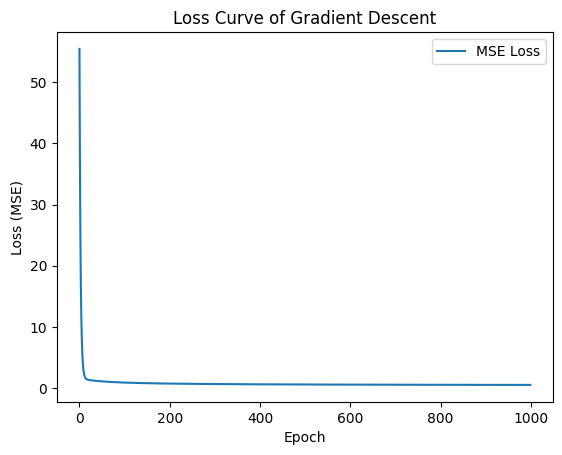

In [2]:
import matplotlib.pyplot as plt
Data = {
    'sample': ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12','S13','S14','S15'],
    'Drug': ['Control','DrugA','DrugB','DrugC','Control',
             'DrugA','DrugB','DrugC','Control','DrugA',
             'DrugB','DrugC','Control','DrugA','DrugB'],
    'Tissue': ['Liver','Heart','Brain','Kidney','Brain',
               'Liver','Heart','Kidney','Brain','Heart',
               'Liver','Kidney','Liver','Brain','Heart'],
    'Time': ['Day1','Day3','Day7','Day1','Day3',
             'Day7','Day1','Day3','Day7','Day1',
             'Day3','Day7','Day1','Day3','Day7'],
    'GeneA': [2.0, 1.5, 0.8, 3.2, 2.5, 1.0, 2.2, 2.9, 1.7, 3.0, 2.1, 2.8, 1.3, 2.4, 1.9],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.8, 0.9, 1.2, 2.0, 1.5, 1.7, 2.3, 1.4, 2.1, 1.6],
    'Phenotype': [5, 7, 6, 9, 8, 4, 7, 10, 6, 11, 7, 9, 5, 8, 6]
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Drug', 'Tissue','Time'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Drug_Control','Drug_DrugA','Drug_DrugB','Drug_DrugC',
                'Tissue_Brain','Tissue_Heart','Tissue_Kidney',
                'Time_Day1','Time_Day3','Time_Day7']].values.astype(float)
X = np.hstack((np.ones((X.shape[0],1)),X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零    
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数   


# ===== 梯度下降 + 记录 loss =====
losses = []
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重  

    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()

In [3]:
Data = {
    'sample': [f"S{i}" for i in range(1,21)],
    'Condition': ['Control','Knockdown','TreatmentA','TreatmentB']*5,
    'Tissue': ['Liver','Heart','Brain','Liver','Heart']*4,
    'GeneA': np.random.uniform(0.5, 3.5, 20),
    'GeneB': np.random.uniform(0.5, 3.5, 20),
    'Phenotype': np.random.randint(4, 12, 20)
}

df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

# 对 GeneA 和 GeneB 做 Z-score 标准化
df_encoded['GeneA'] = (df_encoded['GeneA'] - df_encoded['GeneA'].mean()) / df_encoded['GeneA'].std()
df_encoded['GeneB'] = (df_encoded['GeneB'] - df_encoded['GeneB'].mean()) / df_encoded['GeneB'].std()

X = df_encoded[['GeneA','GeneB',
                'Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

# 添加截距项
X = np.hstack((np.ones((X.shape[0],1)), X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)


import matplotlib.pyplot as plt
# ===== 梯度下降 + 记录 loss =====  
losses = []
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重  

    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)

训练完成后的权重： [[ 4.60384526]
 [-0.33756406]
 [ 0.7249731 ]
 [ 2.1207377 ]
 [-0.00561975]
 [ 1.72080761]
 [ 0.7679197 ]
 [ 2.70698565]
 [ 3.03724783]]
Epoch 200, Loss=2.2514
Epoch 400, Loss=2.2474
Epoch 600, Loss=2.2453
Epoch 800, Loss=2.2441
Epoch 1000, Loss=2.2434


训练完成后的权重： [[ 5.45473311]
 [-0.01191368]
 [ 0.06531132]
 [ 1.13271828]
 [ 2.68463414]
 [ 0.53847938]
 [ 1.0989013 ]
 [ 0.74248133]
 [ 0.69051508]]


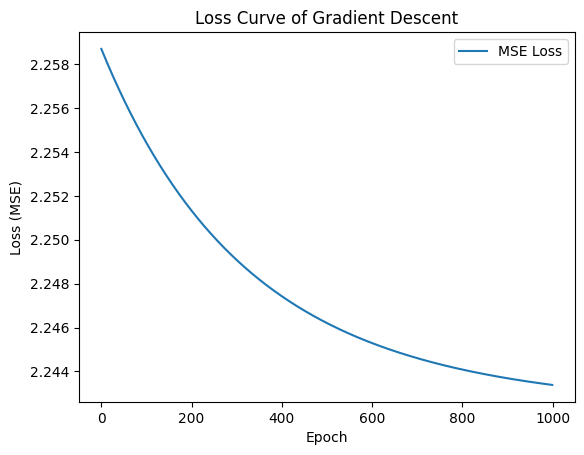

In [ ]:


Data = {
    'sample': [f"S{i}" for i in range(1,21)],
    'Condition': ['Control','Knockdown','TreatmentA','TreatmentB']*5,
    'Tissue': ['Liver','Heart','Brain','Liver','Heart']*4,
    'GeneA': np.random.uniform(0.5, 3.5, 20),
    'GeneB': np.random.uniform(0.5, 3.5, 20),
    'Phenotype': np.random.randint(4, 12, 20)
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[:,0:2] = scaler.fit_transform(X[:,0:2])  # 对 GeneA 和 GeneB 做 Z-score 标准化
X = np.hstack((np.ones((X.shape[0],1)), X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
losses = []   # 记录 loss

for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")    
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ===== 构造数据 =====
Data = {
    'sample': [f"S{i}" for i in range(1,25)],
    'Drug': ['Control','DrugA','DrugB','DrugC']*6,
    'Tissue': ['Liver','Heart','Brain']*8,
    'Time': ['Day1','Day3','Day7']*8,
    'GeneA': np.random.uniform(0.5, 3.5, 24),
    'GeneB': np.random.uniform(0.5, 3.5, 24),
    'GeneC': np.random.uniform(0.5, 3.5, 24),
    'Phenotype': np.random.randint(4, 12, 24)
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Drug', 'Tissue','Time'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','GeneC',
                'Drug_Control','Drug_DrugA','Drug_DrugB','Drug_DrugC',
                'Tissue_Brain','Tissue_Heart','Tissue_Liver',
                'Time_Day1','Time_Day3','Time_Day7']].values.astype(float)

# 对 GeneA、GeneB 和 GeneC 做 Z-score 标准化
scaler = StandardScaler()
X[:,0:3] = scaler.fit_transform(X[:,0:3])

# ===== 添加截距项 =====
X = np.hstack((np.ones((X.shape[0],1)),X))

# ===== 标签 =====
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)

# ===== 梯度下降 =====
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
losses = []   # 记录 loss
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
    
    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)
print("训练完成后的权重：", w)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")    
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()

In [ ]:
X['GeneA'] = (df_encoded['GeneA'] - df_encoded['GeneA'].mean()) / df_encoded['GeneA'].std()
X['GeneB'] = (df_encoded['GeneB'] - df_encoded['GeneB'].mean()) / df_encoded['GeneB'].std()
X['GeneC'] = (df_encoded['GeneC'] - df_encoded['GeneC'].mean()) / df_encoded['GeneC'].std()
